In [1]:
%run ../scripts/notebook_settings_lean.py
from scipy import stats
from horizonplot import horizonplot
from chromwindow import window
from ete3 import Tree

In [2]:
def create_paint_df_ind_compressed(df, ind, mapping, ns_map):
    d = {}
    max_pos = int(df.epos.iloc[-1])
    df = df.loc[df[ind].shift() != df[ind]].reset_index()
    df["epos"] = pd.concat([df.spos.iloc[1:], pd.Series(max_pos)], ignore_index=True)
    d["pos"] = df.spos
    d["end_pos"] = df.epos -1
    d["length"] = df.epos - df.spos
    d["reference"] = df[ind].map(mapping)
    d["n/s"] = d["reference"].map(ns_map)
    d["individual"] = ind[:-2]
    d["haplotype"] = ind[-1:]
    return pd.DataFrame(d)

def stairs(df, start='pos', end='end_pos', pos='pos', endtrim=0):
    "Turn a df with start, end into one with pos to plot as stairs"
    df1 = df.copy(deep=True)
    df2 = df.copy(deep=True)
    df1[pos] = df1[start]
    df2[pos] = df2[end] - endtrim
    return pd.concat([df1, df2]).sort_values([start, end])

Ethiopian olive tests, only chrX and all its varieties.

In [3]:
df_l = []
for c in ["chr{}".format(x) for x in (range(1, 21))] + ["chrX"]:
    genetic_map = "/home/eriks/baboondiversity/data/PG_panu3_recombination_map/mikumi_pyrho_genetic_map_{}.txt"
    chr_recomb = pd.read_csv(genetic_map.format(c), sep=" ")
    df_l.append(chr_recomb)
recomb_df = pd.concat(df_l)

First with the standard setup.

In [4]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/eth_olive_focus/"
mapping_df = pd.read_csv(rfmix_path + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o

north_south_mapping = {'Hamadryas, Ethiopia': 1,
 'Cynocephalus, Central Tanzania': 0,
 'Papio, Senegal': 0,
 'Anubis, Tanzania': 0}

df_l = []
for chrom in ["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

all_chrX
female_chrX
female_ref_chrX


In [5]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
male_IDs = meta_data_samples.loc[meta_data_samples.Sex == "M"].PGDP_ID

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

Removing hap2 from males.

In [6]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
male_IDs = meta_data_samples.loc[meta_data_samples.Sex == "M"].PGDP_ID

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

eth = meta_data_samples.loc[meta_data_samples.C_origin.isin(["Anubis, Ethiopia"])].PGDP_ID

df_eth = length_df.loc[length_df.individual.isin(eth)]
df = df_eth.loc[~(df_eth.individual.isin(male_IDs) & (df_eth.haplotype == "1"))]

In [7]:
df

,pos,end_pos,length,reference,n/s,individual,haplotype,chrom,haplo_ID,start,north,total_north
0,2500194,2888102,387909,"Hamadryas, Ethiopia",1,PD_0720,0,all_chrX,PD_0720_0,2500194,1,387909
1,2888103,4204317,1316215,"Anubis, Tanzania",0,PD_0720,0,all_chrX,PD_0720_0,2888103,-1,-1316215
2,4204318,4534511,330194,"Hamadryas, Ethiopia",1,PD_0720,0,all_chrX,PD_0720_0,4204318,1,330194
3,4534512,6014704,1480193,"Anubis, Tanzania",0,PD_0720,0,all_chrX,PD_0720_0,4534512,-1,-1480193
4,6014705,6442080,427376,"Hamadryas, Ethiopia",1,PD_0720,0,all_chrX,PD_0720_0,6014705,1,427376
...,...,...,...,...,...,...,...,...,...,...,...,...
110,137016682,138252345,1235664,"Anubis, Tanzania",0,PD_0744,1,female_ref_chrX,PD_0744_1,137016682,-1,-1235664
111,138252346,138553424,301079,"Hamadryas, Ethiopia",1,PD_0744,1,female_ref_chrX,PD_0744_1,138252346,1,301079
112,138553425,140173402,1619978,"Anubis, Tanzania",0,PD_0744,1,female_ref_chrX,PD_0744_1,138553425,-1,-1619978
113,140173403,140819175,645773,"Papio, Senegal",0,PD_0744,1,female_ref_chrX,PD_0744_1,140173403,-1,-645773


In [8]:
c_r_g_df = pd.read_csv("../steps/rfmix_stats_df/call_recomb_genes.txt")

df_l = []
for c in df.chrom.unique():
    print(c)
    l_df = df.loc[df.chrom == c].copy()
    if c.endswith("chrX"):
        c = "chrX"
    r_df = recomb_df.loc[(recomb_df.chromosome == c)]
    pos_mapping = dict(zip(r_df.position, r_df["Genetic_Map(cM)"]))
    l_df["start_cM"] = l_df.pos.map(pos_mapping)
    l_df["end"] = l_df.end_pos + 1
    l_df["end_cM"] = l_df.end.map(pos_mapping)
    call_df = c_r_g_df.loc[c_r_g_df.chrom == c]
    df_call_filt = []
    df_l.append(l_df)
df = pd.concat(df_l)
callable_df = call_df.loc[call_df.callable_frac > 0.75].reset_index()
c_s = callable_df.iloc[0].start
c_e, old_end = callable_df.iloc[0].start, 0
# Seems weird, but it makes it work correctly for identifying intervals in filters
r_s = callable_df.iloc[0].cM
sub_df_l, gap_df_l = [], []
for c in df["chrom"].unique():
    print(c)
    s_df = df.loc[df["chrom"] == c].copy()
    for i, row in callable_df.iterrows():
        if c_e != row.start:# or i+1 == len(callable_df):
            sub_df = s_df.loc[(s_df.end_pos > c_s) & (s_df.pos < c_e)]
            sub_df.loc[sub_df.start_cM < r_s, "start_cM"] = r_s
            sub_df.loc[sub_df.end_cM > row.end_cM, "end_cM"] = row.end_cM
            sub_df.loc[sub_df.pos < c_s, "pos"] = c_s
            sub_df.loc[sub_df.end_pos > c_e, "end_pos"] = c_e
            sub_df_l.append(sub_df)
            # Add start/ends
            start_df = sub_df.loc[sub_df.pos == c_s].copy()
            start_df.end_pos, start_df.end_cM, start_df.north = c_s, r_s, 0
            end_df = sub_df.loc[sub_df.end_pos == c_e].copy()
            end_df.pos, end_df.cM, end_df.north = c_e, r_s, 0
            gap_df_l.append(start_df), gap_df_l.append(end_df)
            # update df_l with new slice of fragment_df
            c_s, c_e, r_s = row.start, row.end, row.cM
        else:
            c_e = row.end
df_filt = pd.concat(sub_df_l)
gap_df = pd.concat(gap_df_l)

all_chrX
female_chrX
female_ref_chrX
all_chrX
female_chrX
female_ref_chrX


In [9]:
df['pop'] = df.haplo_ID
df['is_north'] = (df.north == 1).astype(int)
df['is_south'] = (df.north == -1).astype(int)
df = df.sort_values(['pop', 'chrom', 'start'])

df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

haplo_ID_list = list(df.haplo_ID.unique())

In [10]:
df_c = df_f.loc[df_f["chrom"] == "all_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0720,0.393939
PD_0721,0.411043
PD_0722,0.370213
PD_0723,0.441558
PD_0724,0.413502
PD_0725,0.437229
PD_0726,0.459459
PD_0727,0.421739
PD_0728,0.412000


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


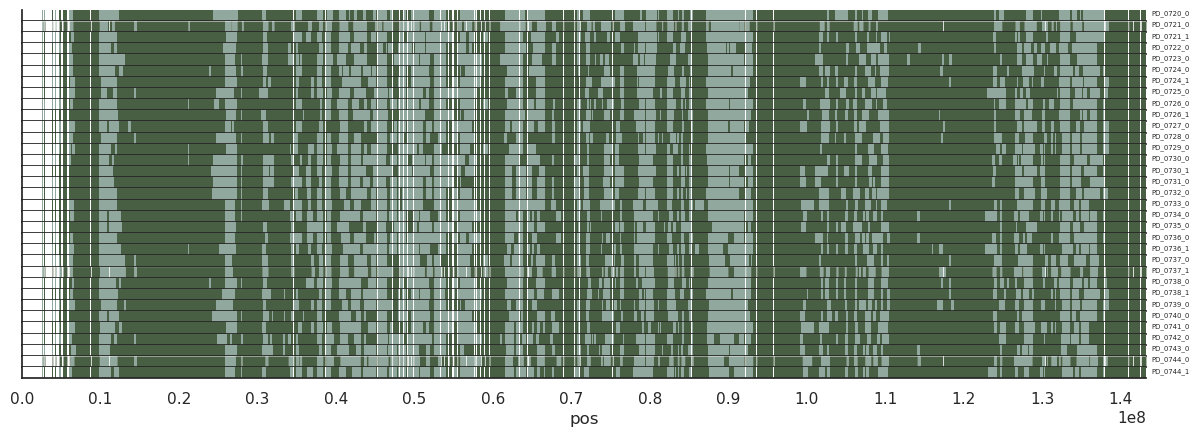

In [11]:
def stairs(df, start='pos', end='end_pos', pos='pos', endtrim=0):
    "Turn a df with start, end into one with pos to plot as stairs"
    df1 = df.copy(deep=True)
    df2 = df.copy(deep=True)
    df1[pos] = df1[start]
    df2[pos] = df2[end] - endtrim
    return pd.concat([df1, df2]).sort_values([start, end])

plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [12]:
df_c = df_f.loc[df_f["chrom"] == "female_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0721,0.320442
PD_0724,0.294434
PD_0726,0.343915
PD_0730,0.353591
PD_0736,0.331570
PD_0737,0.357782
PD_0738,0.310954
PD_0744,0.335125


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


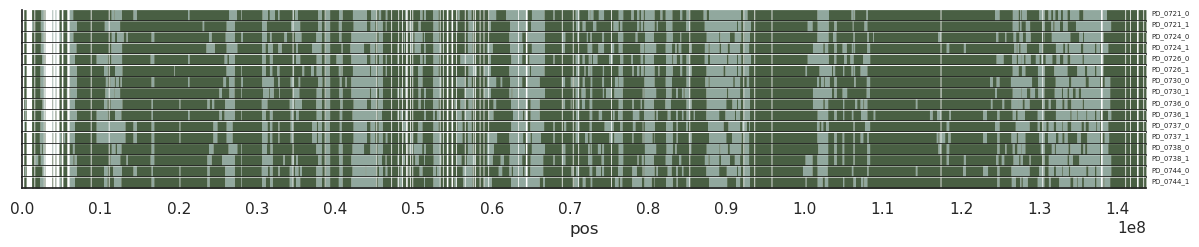

In [13]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [14]:
df_c = df_f.loc[df_f["chrom"] == "female_ref_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0720,0.342742
PD_0721,0.337255
PD_0722,0.304167
PD_0723,0.333333
PD_0724,0.310413
PD_0725,0.355731
PD_0726,0.369048
PD_0727,0.400000
PD_0728,0.326531


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


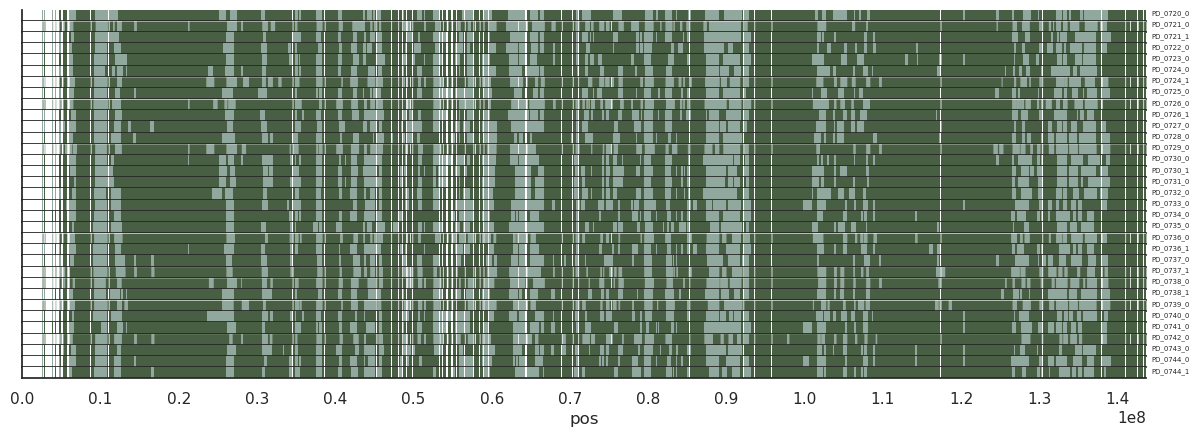

In [15]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

Version without reanalyze.

In [16]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/eth_olive_focus_plain/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/eth_olive_focus/" + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o

north_south_mapping = {'Hamadryas, Ethiopia': 1,
 'Cynocephalus, Central Tanzania': 0,
 'Papio, Senegal': 0,
 'Anubis, Tanzania': 0}

df_l = []
for chrom in ["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

all_chrX
female_chrX
female_ref_chrX


In [17]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
male_IDs = meta_data_samples.loc[meta_data_samples.Sex == "M"].PGDP_ID

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

In [18]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
male_IDs = meta_data_samples.loc[meta_data_samples.Sex == "M"].PGDP_ID

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

eth = meta_data_samples.loc[meta_data_samples.C_origin.isin(["Anubis, Ethiopia"])].PGDP_ID

df_eth = length_df.loc[length_df.individual.isin(eth)]
df = df_eth.loc[~(df_eth.individual.isin(male_IDs) & (df_eth.haplotype == "1"))]

In [19]:
c_r_g_df = pd.read_csv("../steps/rfmix_stats_df/call_recomb_genes.txt")

df_l = []
for c in df.chrom.unique():
    print(c)
    l_df = df.loc[df.chrom == c].copy()
    if c.endswith("chrX"):
        c = "chrX"
    r_df = recomb_df.loc[(recomb_df.chromosome == c)]
    pos_mapping = dict(zip(r_df.position, r_df["Genetic_Map(cM)"]))
    l_df["start_cM"] = l_df.pos.map(pos_mapping)
    l_df["end"] = l_df.end_pos + 1
    l_df["end_cM"] = l_df.end.map(pos_mapping)
    call_df = c_r_g_df.loc[c_r_g_df.chrom == c]
    df_call_filt = []
    df_l.append(l_df)
df = pd.concat(df_l)
callable_df = call_df.loc[call_df.callable_frac > 0.75].reset_index()
c_s = callable_df.iloc[0].start
c_e, old_end = callable_df.iloc[0].start, 0
# Seems weird, but it makes it work correctly for identifying intervals in filters
r_s = callable_df.iloc[0].cM
sub_df_l, gap_df_l = [], []
for i, row in callable_df.iterrows():
    if c_e != row.start:# or i+1 == len(callable_df):
        sub_df = df.loc[(df.end_pos > c_s) & (df.pos < c_e)]
        sub_df.loc[sub_df.start_cM < r_s, "start_cM"] = r_s
        sub_df.loc[sub_df.end_cM > row.end_cM, "end_cM"] = row.end_cM
        sub_df.loc[sub_df.pos < c_s, "pos"] = c_s
        sub_df.loc[sub_df.end_pos > c_e, "end_pos"] = c_e
        sub_df_l.append(sub_df)
        # Add start/ends
        start_df = sub_df.loc[sub_df.pos == c_s].copy()
        start_df.end_pos, start_df.end_cM, start_df.north = c_s, r_s, 0
        end_df = sub_df.loc[sub_df.end_pos == c_e].copy()
        end_df.pos, end_df.cM, end_df.north = c_e, r_s, 0
        gap_df_l.append(start_df), gap_df_l.append(end_df)
        # update df_l with new slice of fragment_df
        c_s, c_e, r_s = row.start, row.end, row.cM
    else:
        c_e = row.end
df_filt = pd.concat(sub_df_l)
gap_df = pd.concat(gap_df_l)

all_chrX
female_chrX
female_ref_chrX


In [20]:
gap_df

,pos,end_pos,length,reference,n/s,individual,haplotype,chrom,haplo_ID,start,north,total_north,start_cM,end,end_cM
0,200000,200000,2383486,"Anubis, Tanzania",0,PD_0721,0,female_chrX,PD_0721_0,37,0,-2383486,1.322269,2383523,1.322269
0,200000,200000,1175344,"Anubis, Tanzania",0,PD_0721,1,female_chrX,PD_0721_1,37,0,-1175344,1.322269,1175381,1.322269
0,200000,200000,2410553,"Anubis, Tanzania",0,PD_0724,0,female_chrX,PD_0724_0,37,0,-2410553,1.322269,2410590,1.322269
0,200000,200000,2319264,"Anubis, Tanzania",0,PD_0724,1,female_chrX,PD_0724_1,37,0,-2319264,1.322269,2319301,1.322269
0,200000,200000,2493318,"Anubis, Tanzania",0,PD_0726,0,female_chrX,PD_0726_0,37,0,-2493318,1.322269,2493355,1.322269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,143200000,143200000,5003847,"Anubis, Tanzania",0,PD_0741,0,female_ref_chrX,PD_0741_0,138659017,0,-5003847,126.235067,143662864,126.816893
129,143200000,143200000,5109439,"Anubis, Tanzania",0,PD_0742,0,female_ref_chrX,PD_0742_0,138553425,0,-5109439,126.235067,143662864,126.816893
123,143200000,143200000,6386615,"Anubis, Tanzania",0,PD_0743,0,female_ref_chrX,PD_0743_0,137276249,0,-6386615,126.235067,143662864,126.816893
122,143200000,143200000,4563993,"Anubis, Tanzania",0,PD_0744,0,female_ref_chrX,PD_0744_0,139098871,0,-4563993,126.235067,143662864,126.816893


In [21]:
callable_df

,index,chrom,start,callable_frac,end,cM,end_cM,average_cM_window,genes,genic
0,25947,chrX,200000,0.95965,300000,1.322269,1.504651,1.823823e-06,"['GYG2', 'GYG2', 'GYG2', 'GYG2', 'GYG2', 'GYG2...",True
1,25948,chrX,300000,0.94918,400000,1.504651,1.703484,1.988331e-06,"['ARSE', 'ARSE', 'ARSE', 'ARSE', 'ARSE', 'ARSE...",True
2,25949,chrX,400000,0.78703,500000,1.703484,1.748264,4.477935e-07,"['ARSF', 'ARSF', 'ARSF', 'ARSF']",True
3,25957,chrX,1200000,0.91308,1300000,2.398092,2.560457,1.623655e-06,[],False
4,25958,chrX,1300000,0.95270,1400000,2.560457,2.648875,8.841842e-07,[],False
...,...,...,...,...,...,...,...,...,...,...
1354,27375,chrX,143000000,0.90390,143100000,126.688052,126.738719,5.066729e-07,"['BRCC3', 'BRCC3', 'BRCC3', 'BRCC3', 'VBP1', '...",True
1355,27376,chrX,143100000,0.94455,143200000,126.738719,126.757529,1.880951e-07,"['VBP1', 'VBP1', 'RAB39B', 'CLIC2']",True
1356,27378,chrX,143300000,0.90454,143400000,126.783155,126.816893,3.373798e-07,"['TMLHE', 'TMLHE', 'TMLHE', 'TMLHE']",True
1357,27379,chrX,143400000,0.78855,143500000,126.816893,126.844878,2.798504e-07,['SPRY3'],True


In [22]:
df['pop'] = df.haplo_ID
df['is_north'] = (df.north == 1).astype(int)
df['is_south'] = (df.north == -1).astype(int)
df = df.sort_values(['pop', 'chrom', 'start'])

df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "all_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0720,0.393939
PD_0721,0.411043
PD_0722,0.370213
PD_0723,0.441558
PD_0724,0.413502
PD_0725,0.437229
PD_0726,0.459459
PD_0727,0.421739
PD_0728,0.412000


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


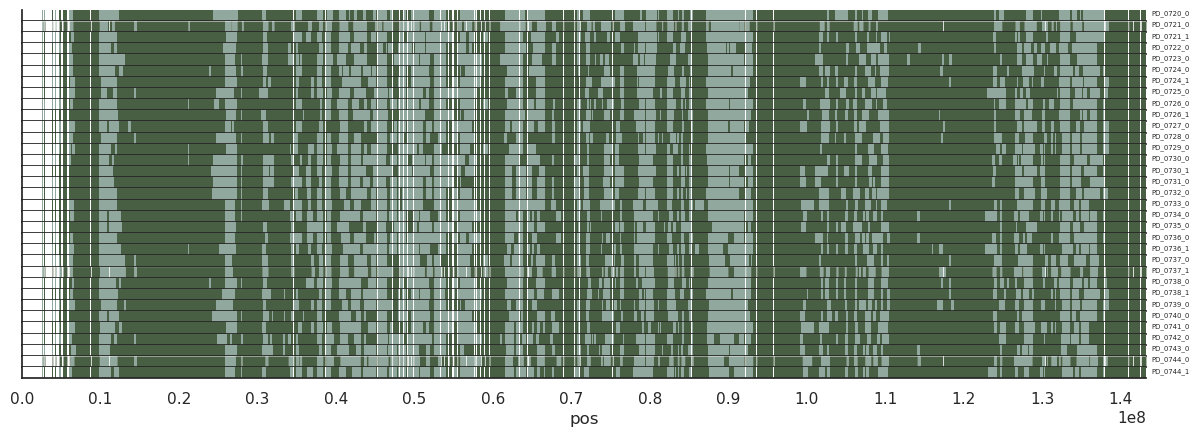

In [23]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [24]:
df['pop'] = df.haplo_ID
df['is_north'] = (df.north == 1).astype(int)
df['is_south'] = (df.north == -1).astype(int)
df = df.sort_values(['pop', 'chrom', 'start'])

df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "female_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0721,0.324022
PD_0724,0.297641
PD_0726,0.347594
PD_0730,0.357542
PD_0736,0.335116
PD_0737,0.361664
PD_0738,0.314286
PD_0744,0.338768


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


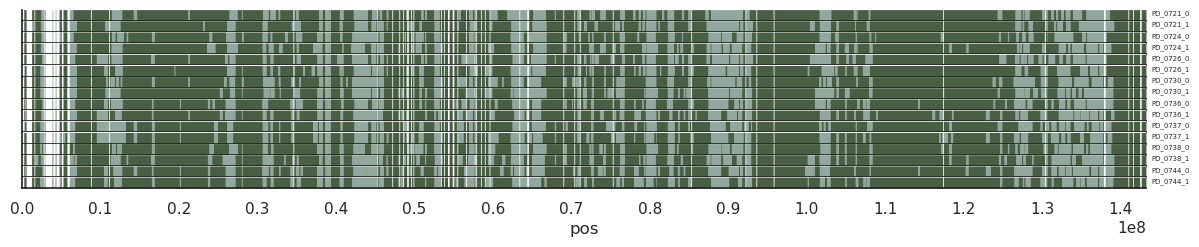

In [25]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [26]:
df['pop'] = df.haplo_ID
df['is_north'] = (df.north == 1).astype(int)
df['is_south'] = (df.north == -1).astype(int)
df = df.sort_values(['pop', 'chrom', 'start'])

df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "female_ref_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0720,0.346939
PD_0721,0.341270
PD_0722,0.308017
PD_0723,0.337449
PD_0724,0.314115
PD_0725,0.360000
PD_0726,0.373494
PD_0727,0.405172
PD_0728,0.330579


In [27]:
df_c

,pos,end_pos,length,reference,n/s,individual,haplotype,chrom,haplo_ID,start,north,total_north,start_cM,end,end_cM,pop,is_north,is_south,is_filtered
0,2500194,2700000,577051,"Hamadryas, Ethiopia",1,PD_0720,0,female_ref_chrX,PD_0720_0,2500194,1,577051,3.936488,3077245,4.323602,PD_0720_0,1,0,0
0,2700000,2700000,577051,"Hamadryas, Ethiopia",1,PD_0720,0,female_ref_chrX,PD_0720_0,2500194,0,577051,3.936488,3077245,4.323602,PD_0720_0,0,0,1
0,2800000,2800000,577051,"Hamadryas, Ethiopia",1,PD_0720,0,female_ref_chrX,PD_0720_0,2500194,0,577051,4.228790,3077245,4.228790,PD_0720_0,0,0,1
0,2800000,2900000,577051,"Hamadryas, Ethiopia",1,PD_0720,0,female_ref_chrX,PD_0720_0,2500194,1,577051,4.228790,3077245,4.504060,PD_0720_0,1,0,0
0,2900000,2900000,577051,"Hamadryas, Ethiopia",1,PD_0720,0,female_ref_chrX,PD_0720_0,2500194,0,577051,4.228790,3077245,4.504060,PD_0720_0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,141600000,142400000,2843688,"Anubis, Tanzania",0,PD_0744,1,female_ref_chrX,PD_0744_1,140819176,-1,-2843688,125.493132,143662864,126.316094,PD_0744_1,0,1,0
114,142400000,142400000,2843688,"Anubis, Tanzania",0,PD_0744,1,female_ref_chrX,PD_0744_1,140819176,0,-2843688,125.493132,143662864,126.316094,PD_0744_1,0,0,1
114,142600000,142600000,2843688,"Anubis, Tanzania",0,PD_0744,1,female_ref_chrX,PD_0744_1,140819176,0,-2843688,126.235067,143662864,126.235067,PD_0744_1,0,0,1
114,142600000,143200000,2843688,"Anubis, Tanzania",0,PD_0744,1,female_ref_chrX,PD_0744_1,140819176,-1,-2843688,126.235067,143662864,126.816893,PD_0744_1,0,1,0


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


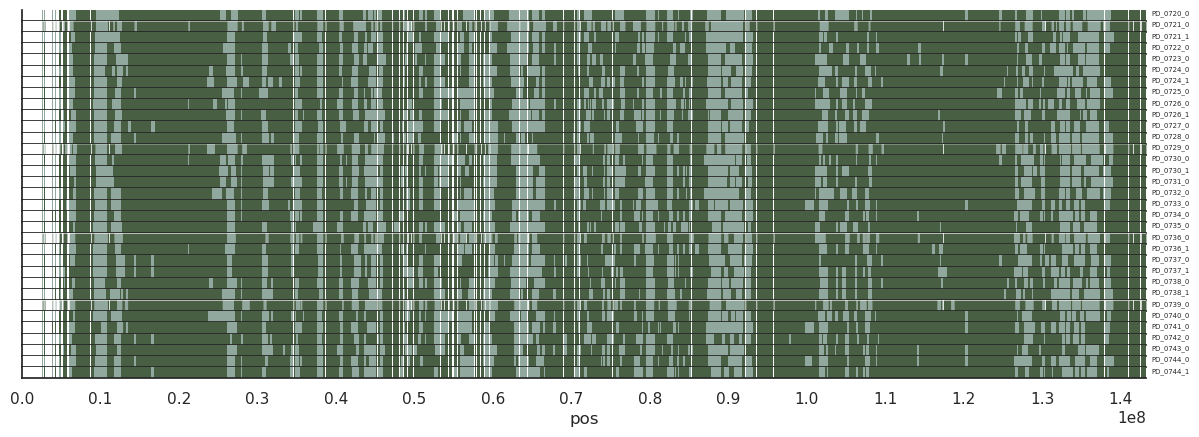

In [28]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

Time for the much more difficult case - Ruaha.

In [29]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_focus/"
mapping_df = pd.read_csv(rfmix_path + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
    
north_south_mapping = {'Hamadryas, Ethiopia': 1,
 'Kindae, Zambia': 0,
 'Papio, Senegal': 1,
 'Ursinus, Zambia': 0}

df_l = []
for chrom in ["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

all_chrX
female_chrX
female_ref_chrX


In [30]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
male_IDs = meta_data_samples.loc[meta_data_samples.Sex == "M"].PGDP_ID

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

In [31]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
male_IDs = meta_data_samples.loc[meta_data_samples.Sex == "M"].PGDP_ID

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

ruaha = meta_data_samples.loc[meta_data_samples.Origin.isin(["Ruaha, Tanzania"])].PGDP_ID

df_ruaha = length_df.loc[length_df.individual.isin(ruaha)]
df = df_ruaha.loc[~(df_ruaha.individual.isin(male_IDs) & (df_ruaha.haplotype == "1"))]

In [32]:
c_r_g_df = pd.read_csv("../steps/rfmix_stats_df/call_recomb_genes.txt")

df_l = []
for c in df.chrom.unique():
    print(c)
    l_df = df.loc[df.chrom == c].copy()
    if c.endswith("chrX"):
        c = "chrX"
    r_df = recomb_df.loc[(recomb_df.chromosome == c)]
    pos_mapping = dict(zip(r_df.position, r_df["Genetic_Map(cM)"]))
    l_df["start_cM"] = l_df.pos.map(pos_mapping)
    l_df["end"] = l_df.end_pos + 1
    l_df["end_cM"] = l_df.end.map(pos_mapping)
    call_df = c_r_g_df.loc[c_r_g_df.chrom == c]
    df_call_filt = []
    df_l.append(l_df)
df_r = pd.concat(df_l)
callable_df = call_df.loc[call_df.callable_frac > 0.75].reset_index()
c_s = callable_df.iloc[0].start
c_e, old_end = callable_df.iloc[0].start, 0
# Seems weird, but it makes it work correctly for identifying intervals in filters
r_s = callable_df.iloc[0].cM
sub_df_l, gap_df_l = [], []
for c in df_r["chrom"].unique():
    print(c)
    s_df = df_r.loc[df_r["chrom"] == c].copy()
    for i, row in callable_df.iterrows():
        if c_e != row.start:# or i+1 == len(callable_df):
            sub_df = s_df.loc[(s_df.end_pos > c_s) & (s_df.pos < c_e)]
            sub_df.loc[sub_df.start_cM < r_s, "start_cM"] = r_s
            sub_df.loc[sub_df.end_cM > row.end_cM, "end_cM"] = row.end_cM
            sub_df.loc[sub_df.pos < c_s, "pos"] = c_s
            sub_df.loc[sub_df.end_pos > c_e, "end_pos"] = c_e
            sub_df_l.append(sub_df)
            # Add start/ends
            start_df = sub_df.loc[sub_df.pos == c_s].copy()
            start_df.end_pos, start_df.end_cM, start_df.north = c_s, r_s, 0
            end_df = sub_df.loc[sub_df.end_pos == c_e].copy()
            end_df.pos, end_df.cM, end_df.north = c_e, r_s, 0
            gap_df_l.append(start_df), gap_df_l.append(end_df)
            # update df_l with new slice of fragment_df
            c_s, c_e, r_s = row.start, row.end, row.cM
        else:
            c_e = row.end
df_filt = pd.concat(sub_df_l)
gap_df = pd.concat(gap_df_l)

all_chrX
female_chrX
female_ref_chrX
all_chrX
female_chrX
female_ref_chrX


In [33]:
df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "all_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0213,0.268168
PD_0214,0.274096
PD_0215,0.266968
PD_0216,0.252918
PD_0217,0.256148
PD_0503,0.265885


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


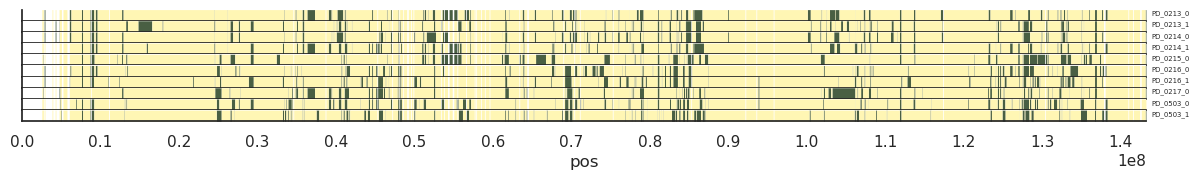

In [34]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [35]:
df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "female_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0213,0.196162
PD_0214,0.219512
PD_0216,0.175758
PD_0503,0.196000


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


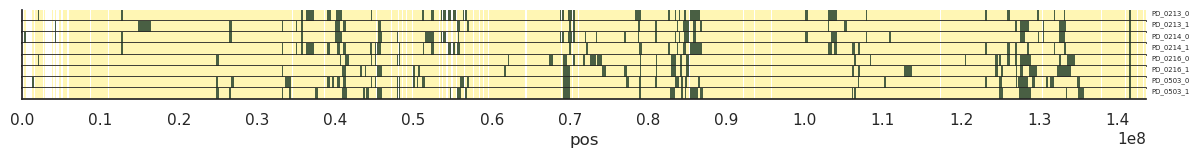

In [36]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [37]:
df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "female_ref_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0213,0.192308
PD_0214,0.216797
PD_0215,0.231405
PD_0216,0.171963
PD_0217,0.176471
PD_0503,0.177388


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


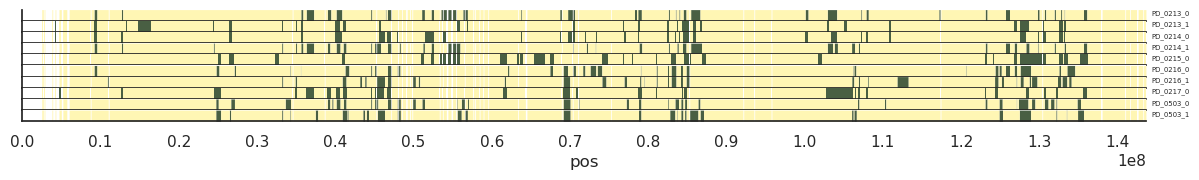

In [38]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [39]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_focus_plain/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/tanzania_focus/" + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
    
north_south_mapping = {'Hamadryas, Ethiopia': 1,
 'Kindae, Zambia': 0,
 'Papio, Senegal': 1,
 'Ursinus, Zambia': 0}

df_l = []
for chrom in ["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

all_chrX
female_chrX
female_ref_chrX


In [40]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
male_IDs = meta_data_samples.loc[meta_data_samples.Sex == "M"].PGDP_ID

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

In [41]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
male_IDs = meta_data_samples.loc[meta_data_samples.Sex == "M"].PGDP_ID

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

ruaha = meta_data_samples.loc[meta_data_samples.Origin.isin(["Ruaha, Tanzania"])].PGDP_ID

df_ruaha = length_df.loc[length_df.individual.isin(ruaha)]
df = df_ruaha.loc[~(df_ruaha.individual.isin(male_IDs) & (df_ruaha.haplotype == "1"))]

In [42]:
c_r_g_df = pd.read_csv("../steps/rfmix_stats_df/call_recomb_genes.txt")

df_l = []
for c in df.chrom.unique():
    print(c)
    l_df = df.loc[df.chrom == c].copy()
    if c.endswith("chrX"):
        c = "chrX"
    r_df = recomb_df.loc[(recomb_df.chromosome == c)]
    pos_mapping = dict(zip(r_df.position, r_df["Genetic_Map(cM)"]))
    l_df["start_cM"] = l_df.pos.map(pos_mapping)
    l_df["end"] = l_df.end_pos + 1
    l_df["end_cM"] = l_df.end.map(pos_mapping)
    call_df = c_r_g_df.loc[c_r_g_df.chrom == c]
    df_call_filt = []
    df_l.append(l_df)
df_r = pd.concat(df_l)
callable_df = call_df.loc[call_df.callable_frac > 0.75].reset_index()
c_s = callable_df.iloc[0].start
c_e, old_end = callable_df.iloc[0].start, 0
# Seems weird, but it makes it work correctly for identifying intervals in filters
r_s = callable_df.iloc[0].cM
sub_df_l, gap_df_l = [], []
for c in df_r["chrom"].unique():
    print(c)
    s_df = df_r.loc[df_r["chrom"] == c].copy()
    for i, row in callable_df.iterrows():
        if c_e != row.start:# or i+1 == len(callable_df):
            sub_df = s_df.loc[(s_df.end_pos > c_s) & (s_df.pos < c_e)]
            sub_df.loc[sub_df.start_cM < r_s, "start_cM"] = r_s
            sub_df.loc[sub_df.end_cM > row.end_cM, "end_cM"] = row.end_cM
            sub_df.loc[sub_df.pos < c_s, "pos"] = c_s
            sub_df.loc[sub_df.end_pos > c_e, "end_pos"] = c_e
            sub_df_l.append(sub_df)
            # Add start/ends
            start_df = sub_df.loc[sub_df.pos == c_s].copy()
            start_df.end_pos, start_df.end_cM, start_df.north = c_s, r_s, 0
            end_df = sub_df.loc[sub_df.end_pos == c_e].copy()
            end_df.pos, end_df.cM, end_df.north = c_e, r_s, 0
            gap_df_l.append(start_df), gap_df_l.append(end_df)
            # update df_l with new slice of fragment_df
            c_s, c_e, r_s = row.start, row.end, row.cM
        else:
            c_e = row.end
df_filt = pd.concat(sub_df_l)
gap_df = pd.concat(gap_df_l)

all_chrX
female_chrX
female_ref_chrX
all_chrX
female_chrX
female_ref_chrX


In [43]:
df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "all_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0213,0.268168
PD_0214,0.274096
PD_0215,0.266968
PD_0216,0.252918
PD_0217,0.256148
PD_0503,0.265885


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


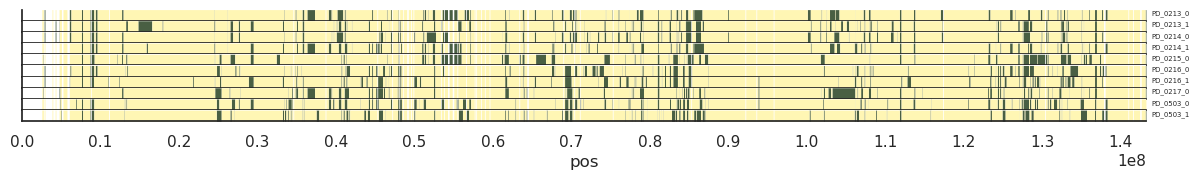

In [44]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [45]:
df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "female_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0213,0.196162
PD_0214,0.219512
PD_0216,0.175758
PD_0503,0.196000


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


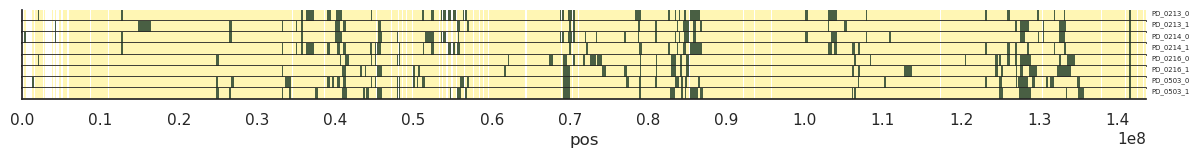

In [46]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))

In [47]:
df_f = pd.concat([df_filt, gap_df])
df_f['pop'] = df_f.haplo_ID
df_f['is_north'] = (df_f.north == 1).astype(int)
df_f['is_south'] = (df_f.north == -1).astype(int)
df_f['is_filtered'] = (df_f.north == 0).astype(int)
df_f = df_f.sort_values(['pop', 'chrom', 'pos', 'is_north', 'is_south'])

df_c = df_f.loc[df_f["chrom"] == "female_ref_chrX"]
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()
haplo_ID_list = list(df_c.haplo_ID.unique())
df_c.groupby(["individual"])[["n/s"]].mean()

,n/s
individual,
PD_0213,0.192308
PD_0214,0.216797
PD_0215,0.231405
PD_0216,0.171963
PD_0217,0.176471
PD_0503,0.177388


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


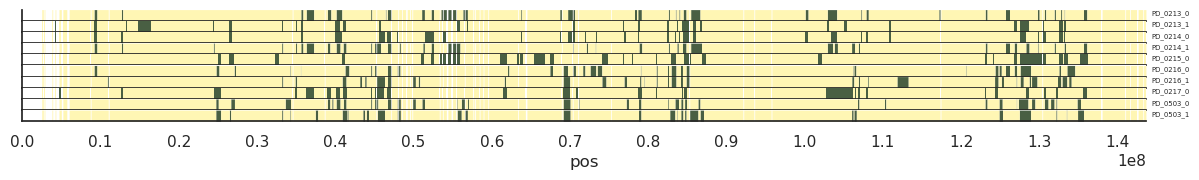

In [48]:
plot_df = stairs(df_c).sort_values(['pop', 'chrom', 'pos', 'end_pos', 'is_filtered'])
g = sns.FacetGrid(plot_df, col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.145, aspect=100,
                    margin_titles=True, gridspec_kws={'hspace':0.0})

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=olive_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_list, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(df.pos)+1, 10000000))